In [3]:
work_dir = "/scratch/mjehangir/manuscript_figures/manuscript_data/"
setwd(work_dir)

In [5]:
library(openxlsx)
library(dplyr)
library(tidyverse)
library(tidyr)
library(ggplot2)
#library(pheatmap)
library(DescTools)
library(ggpubr)

In [8]:
telomeres <- read.csv("gliomas_telomers.csv", header = TRUE, sep = ",", stringsAsFactors = FALSE)
segmentation <- read.table("mean_centered_normalization_segmentation_v2.seg", header = TRUE, sep = "\t", stringsAsFactors = FALSE)
chrom_arms <- read.table("chm13_p_q_arm_length.tsv", header = TRUE, sep = "\t")

In [9]:
head(segmentation)
head(chrom_arms)
head(telomeres)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean
,<chr>,<chr>,<int>,<int>,<int>,<dbl>
1,2436A,chr1,200151,28021140,130,0.8417
2,2436A,chr1,142707663,142907814,2,2.1416
3,2436A,chr10,88303635,101719380,68,0.7949
4,2436A,chr10,101919615,104722905,15,0.6843
5,2436A,chr10,104923140,112932540,41,0.7685
6,2436A,chr10,113132775,120741705,39,0.3861


,Chromosome,Start,End,Length,Arm
,<chr>,<int>,<int>,<int>,<chr>
1,chr1,0,124048267,124048267,p
2,chr1,124048267,248387328,124339061,q
3,chr10,0,40649191,40649191,p
4,chr10,40649191,134758134,94108943,q
5,chr11,0,52743313,52743313,p
6,chr11,52743313,135127769,82384456,q


,Sample_prefix,chr,final_average_TL_p75,chr_order,arm
,<chr>,<chr>,<dbl>,<int>,<chr>
1,2436A,chr1p,5221.000,1,p
2,2436A,chr1q,5051.167,1,q
3,3188,chr1p,1642.500,1,p
4,3188,chr1q,3086.500,1,q
5,3988,chr1p,2347.500,1,p
6,3988,chr1q,5083.000,1,q


In [10]:
#Rename the columns, and also rename seg.mean as MEAN_LOG2_COPY_RATIO based on the previous normalization
segmentation <- segmentation %>%
  rename(chr = chrom, SampleID = ID, START = loc.start, END = loc.end, MEAN_LOG2_COPY_RATIO	= seg.mean)

In [11]:
head(segmentation)

,SampleID,chr,START,END,num.mark,MEAN_LOG2_COPY_RATIO
,<chr>,<chr>,<int>,<int>,<int>,<dbl>
1,2436A,chr1,200151,28021140,130,0.8417
2,2436A,chr1,142707663,142907814,2,2.1416
3,2436A,chr10,88303635,101719380,68,0.7949
4,2436A,chr10,101919615,104722905,15,0.6843
5,2436A,chr10,104923140,112932540,41,0.7685
6,2436A,chr10,113132775,120741705,39,0.3861


In [12]:
# Rename the 'Chromosome' column to 'chr' from chrom_arms dataset

colnames(chrom_arms)[colnames(chrom_arms) == "Chromosome"] <- "chr"

# Create a new column combining 'chr' and 'Arm'
chrom_arms$chr <- paste(chrom_arms$chr, chrom_arms$Arm, sep = "")

# Remove the 'Arm' column
chrom_arms$Arm <- NULL

In [13]:
head(chrom_arms)

,chr,Start,End,Length
,<chr>,<int>,<int>,<int>
1,chr1p,0,124048267,124048267
2,chr1q,124048267,248387328,124339061
3,chr10p,0,40649191,40649191
4,chr10q,40649191,134758134,94108943
5,chr11p,0,52743313,52743313
6,chr11q,52743313,135127769,82384456


In [16]:

# Define your chromosome arms list as a dataframe (assuming it's called `chrom_arms`):
chrom_arms <- data.frame(
  chr = c("chr1p", "chr1q", "chr10p", "chr10q", "chr11p", "chr11q", "chr12p", "chr12q", "chr13p", "chr13q",
          "chr14p", "chr14q", "chr15p", "chr15q", "chr16p", "chr16q", "chr17p", "chr17q", "chr18p", "chr18q",
          "chr19p", "chr19q", "chr2p", "chr2q", "chr20p", "chr20q", "chr21p", "chr21q", "chr22p", "chr22q",
          "chr3p", "chr3q", "chr4p", "chr4q", "chr5p", "chr5q", "chr6p", "chr6q", "chr7p", "chr7q", "chr8p", "chr8q", "chr9p", "chr9q"),
  Start = c(0, 124048267, 0, 40649191, 0, 52743313, 0, 35911664, 0, 16522942, 0, 11400261, 0, 17186630, 0, 36838903,
           0, 25689679, 0, 18449624, 0, 27792923, 0, 93503283, 0, 28012753, 0, 11134529, 0, 14249622, 0, 94076514,
           0, 52452474, 0, 48317879, 0, 59672548, 0, 62064435, 0, 45270456, 0, 46267185),
  End = c(124048267, 248387328, 40649191, 134758134, 52743313, 135127769, 35911664, 133324548, 16522942, 113566686,
          11400261, 101161492, 17186630, 99753195, 36838903, 96330374, 25689679, 84276897, 18449624, 80542538,
          27792923, 61707364, 93503283, 242696752, 28012753, 66210255, 11134529, 45090682, 14249622, 51324926,
          94076514, 201105948, 52452474, 193574945, 48317879, 182045439, 59672548, 172126628, 62064435, 160567428,
          45270456, 146259331, 46267185, 150617247),
  Length = c(124048267, 124339061, 40649191, 94108943, 52743313, 82384456, 35911664, 97412884, 16522942, 97043744,
             11400261, 89761231, 17186630, 82566565, 36838903, 59491471, 25689679, 58587218, 18449624, 62092914,
             27792923, 33914441, 93503283, 149193469, 28012753, 38197502, 11134529, 33956153, 14249622, 37075304,
             94076514, 107029434, 52452474, 141122471, 48317879, 133727560, 59672548, 112454080, 62064435, 98502993,
             45270456, 100988875, 46267185, 104350062)
)

# Modify the 'chr' column in segmentation to include p or q arm
segmentation_with_arms <- segmentation %>%
  mutate(
    # Add 'p' or 'q' based on START and END for each chromosome
    assigned_arm = case_when(
      chr == "chr1" & START < 124048267 ~ "chr1p",
      chr == "chr1" & START >= 124048267 ~ "chr1q",
      chr == "chr10" & START < 40649191 ~ "chr10p",
      chr == "chr10" & START >= 40649191 ~ "chr10q",
      chr == "chr11" & START < 52743313 ~ "chr11p",
      chr == "chr11" & START >= 52743313 ~ "chr11q",
      chr == "chr12" & START < 35911664 ~ "chr12p",
      chr == "chr12" & START >= 35911664 ~ "chr12q",
      chr == "chr13" & START < 16522942 ~ "chr13p",
      chr == "chr13" & START >= 16522942 ~ "chr13q",
      chr == "chr14" & START < 11400261 ~ "chr14p",
      chr == "chr14" & START >= 11400261 ~ "chr14q",
      chr == "chr15" & START < 17186630 ~ "chr15p",
      chr == "chr15" & START >= 17186630 ~ "chr15q",
      chr == "chr16" & START < 36838903 ~ "chr16p",
      chr == "chr16" & START >= 36838903 ~ "chr16q",
      chr == "chr17" & START < 25689679 ~ "chr17p",
      chr == "chr17" & START >= 25689679 ~ "chr17q",
      chr == "chr18" & START < 18449624 ~ "chr18p",
      chr == "chr18" & START >= 18449624 ~ "chr18q",
      chr == "chr19" & START < 27792923 ~ "chr19p",
      chr == "chr19" & START >= 27792923 ~ "chr19q",
      chr == "chr2" & START < 93503283 ~ "chr2p",
      chr == "chr2" & START >= 93503283 ~ "chr2q",
      chr == "chr20" & START < 28012753 ~ "chr20p",
      chr == "chr20" & START >= 28012753 ~ "chr20q",
      chr == "chr21" & START < 11134529 ~ "chr21p",
      chr == "chr21" & START >= 11134529 ~ "chr21q",
      chr == "chr22" & START < 14249622 ~ "chr22p",
      chr == "chr22" & START >= 14249622 ~ "chr22q",
      chr == "chr3" & START < 94076514 ~ "chr3p",
      chr == "chr3" & START >= 94076514 ~ "chr3q",
      chr == "chr4" & START < 52452474 ~ "chr4p",
      chr == "chr4" & START >= 52452474 ~ "chr4q",
      chr == "chr5" & START < 48317879 ~ "chr5p",
      chr == "chr5" & START >= 48317879 ~ "chr5q",
      chr == "chr6" & START < 59672548 ~ "chr6p",
      chr == "chr6" & START >= 59672548 ~ "chr6q",
      chr == "chr7" & START < 62064435 ~ "chr7p",
      chr == "chr7" & START >= 62064435 ~ "chr7q",
      chr == "chr8" & START < 45270456 ~ "chr8p",
      chr == "chr8" & START >= 45270456 ~ "chr8q",
      chr == "chr9" & START < 46267185 ~ "chr9p",
      chr == "chr9" & START >= 46267185 ~ "chr9q",
      TRUE ~ as.character(chr)
    )
  )

# Join with chrom_arms to ensure matching arms based on chromosome names
merged_data <- left_join(segmentation_with_arms, chrom_arms, by = c("assigned_arm" = "chr"))


In [17]:
head(merged_data)

,SampleID,chr,START,END,num.mark,MEAN_LOG2_COPY_RATIO,assigned_arm,Start,End,Length
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1,2436A,chr1,200151,28021140,130,0.8417,chr1p,0,124048267,124048267
2,2436A,chr1,142707663,142907814,2,2.1416,chr1q,124048267,248387328,124339061
3,2436A,chr10,88303635,101719380,68,0.7949,chr10q,40649191,134758134,94108943
4,2436A,chr10,101919615,104722905,15,0.6843,chr10q,40649191,134758134,94108943
5,2436A,chr10,104923140,112932540,41,0.7685,chr10q,40649191,134758134,94108943
6,2436A,chr10,113132775,120741705,39,0.3861,chr10q,40649191,134758134,94108943


In [36]:
# Ensure seg.mean is numeric
segmentation$seg.mean <- as.numeric(segmentation$seg.mean)

# Calculate percentiles for seg.mean
percentiles <- quantile(segmentation$seg.mean, probs = c(0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99), na.rm = TRUE)

# Print percentiles
print("Percentiles for seg.mean:")
print(percentiles)

ERROR: Error in `$<-.data.frame`(`*tmp*`, seg.mean, value = numeric(0)): replacement has 0 rows, data has 2019


In [38]:
# Step 1: Classify segments as gain, loss, or neutral
merged_data <- merged_data %>%
  mutate(
    classification = case_when(
      MEAN_LOG2_COPY_RATIO > 1.15 ~ "gain",
      MEAN_LOG2_COPY_RATIO < 0.66 ~ "loss",
      TRUE ~ "neutral"
    )
  )

# Step 2: Calculate the total lengths of gain, loss, and neutral for each arm in each sample
arm_summary <- merged_data %>%
  group_by(SampleID, chr, assigned_arm, classification) %>%
  summarize(
    total_length = sum(END - START),
    .groups = "drop"
  )

# Step 3: Merge the arm length into the summary for proportions
arm_summary <- arm_summary %>%
  left_join(
    merged_data %>% select(assigned_arm, Length) %>% distinct(),
    by = "assigned_arm"
  ) %>%
  mutate(
    proportion = total_length / Length
  )

# Step 4: Reshape the data for clarity (optional)
proportion_summary <- arm_summary %>%
  pivot_wider(
    names_from = classification,
    values_from = c(total_length, proportion),
    values_fill = 0  # Fill missing values with 0
  )

# View the final summarized data
head(proportion_summary)


SampleID,chr,assigned_arm,Length,total_length_neutral,total_length_gain,total_length_loss,proportion_neutral,proportion_gain,proportion_loss
<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
2436A,chr1,chr1p,124048267,27820989,0,0,0.22427552,0.000000000,0.0000000
2436A,chr1,chr1q,124339061,0,200151,0,0.00000000,0.001609719,0.0000000
2436A,chr10,chr10q,94108943,26230785,0,18621836,0.27872787,0.000000000,0.1978753
2436A,chr11,chr11p,52743313,3002850,0,0,0.05693328,0.000000000,0.0000000
2436A,chr12,chr12p,35911664,4003740,0,0,0.11148857,0.000000000,0.0000000
2436A,chr12,chr12q,97412884,9809163,0,0,0.10069677,0.000000000,0.0000000


In [20]:
print(proportion_summary)

# A tibble: 586 × 10
   SampleID chr   assigned_arm    Length total_length_neutral total_length_gain
   <chr>    <chr> <chr>            <dbl>                <int>             <int>
 1 2436A    chr1  chr1p        124048267             27820989                 0
 2 2436A    chr1  chr1q        124339061                    0            200151
 3 2436A    chr10 chr10q        94108943             26230785                 0
 4 2436A    chr11 chr11p        52743313              3002850                 0
 5 2436A    chr12 chr12p        35911664              4003740                 0
 6 2436A    chr12 chr12q        97412884              9809163                 0
 7 2436A    chr14 chr14q        89761231              1001600                 0
 8 2436A    chr15 chr15q        82566565                    0           1602464
 9 2436A    chr16 chr16p        36838903             38251783                 0
10 2436A    chr16 chr16q        59491471              5607588                 0
# ℹ 576 more rows
#

Warning message:
“There were 6 warnings in `summarize()`.
The first warning was:
ℹ In argument: `pearson_corr_gain = cor(final_average_TL_p75, proportion_gain,
  use = "complete.obs")`.
ℹ In group 10: `assigned_arm = "chr16p"`.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 5 remaining warnings.”


# A tibble: 40 × 5
   assigned_arm pearson_corr_gain p_value_gain pearson_corr_loss p_value_loss
   <chr>                    <dbl>        <dbl>             <dbl>        <dbl>
 1 chr10p                  -0.271        0.449            -0.305       0.392 
 2 chr10q                  -0.162        0.535            -0.559       0.0196
 3 chr11p                   0.221        0.447            -0.301       0.295 
 4 chr11q                  -0.234        0.400             0.296       0.283 
 5 chr12p                   0.408        0.148            -0.449       0.107 
 6 chr12q                   0.323        0.206            -0.122       0.640 
 7 chr13q                  -0.427        0.166             0.384       0.218 
 8 chr14q                   0.109        0.647            -0.297       0.204 
 9 chr15q                  -0.256        0.321             0.235       0.363 
10 chr16p                  NA           NA                -0.379       0.164 
# ℹ 30 more rows


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


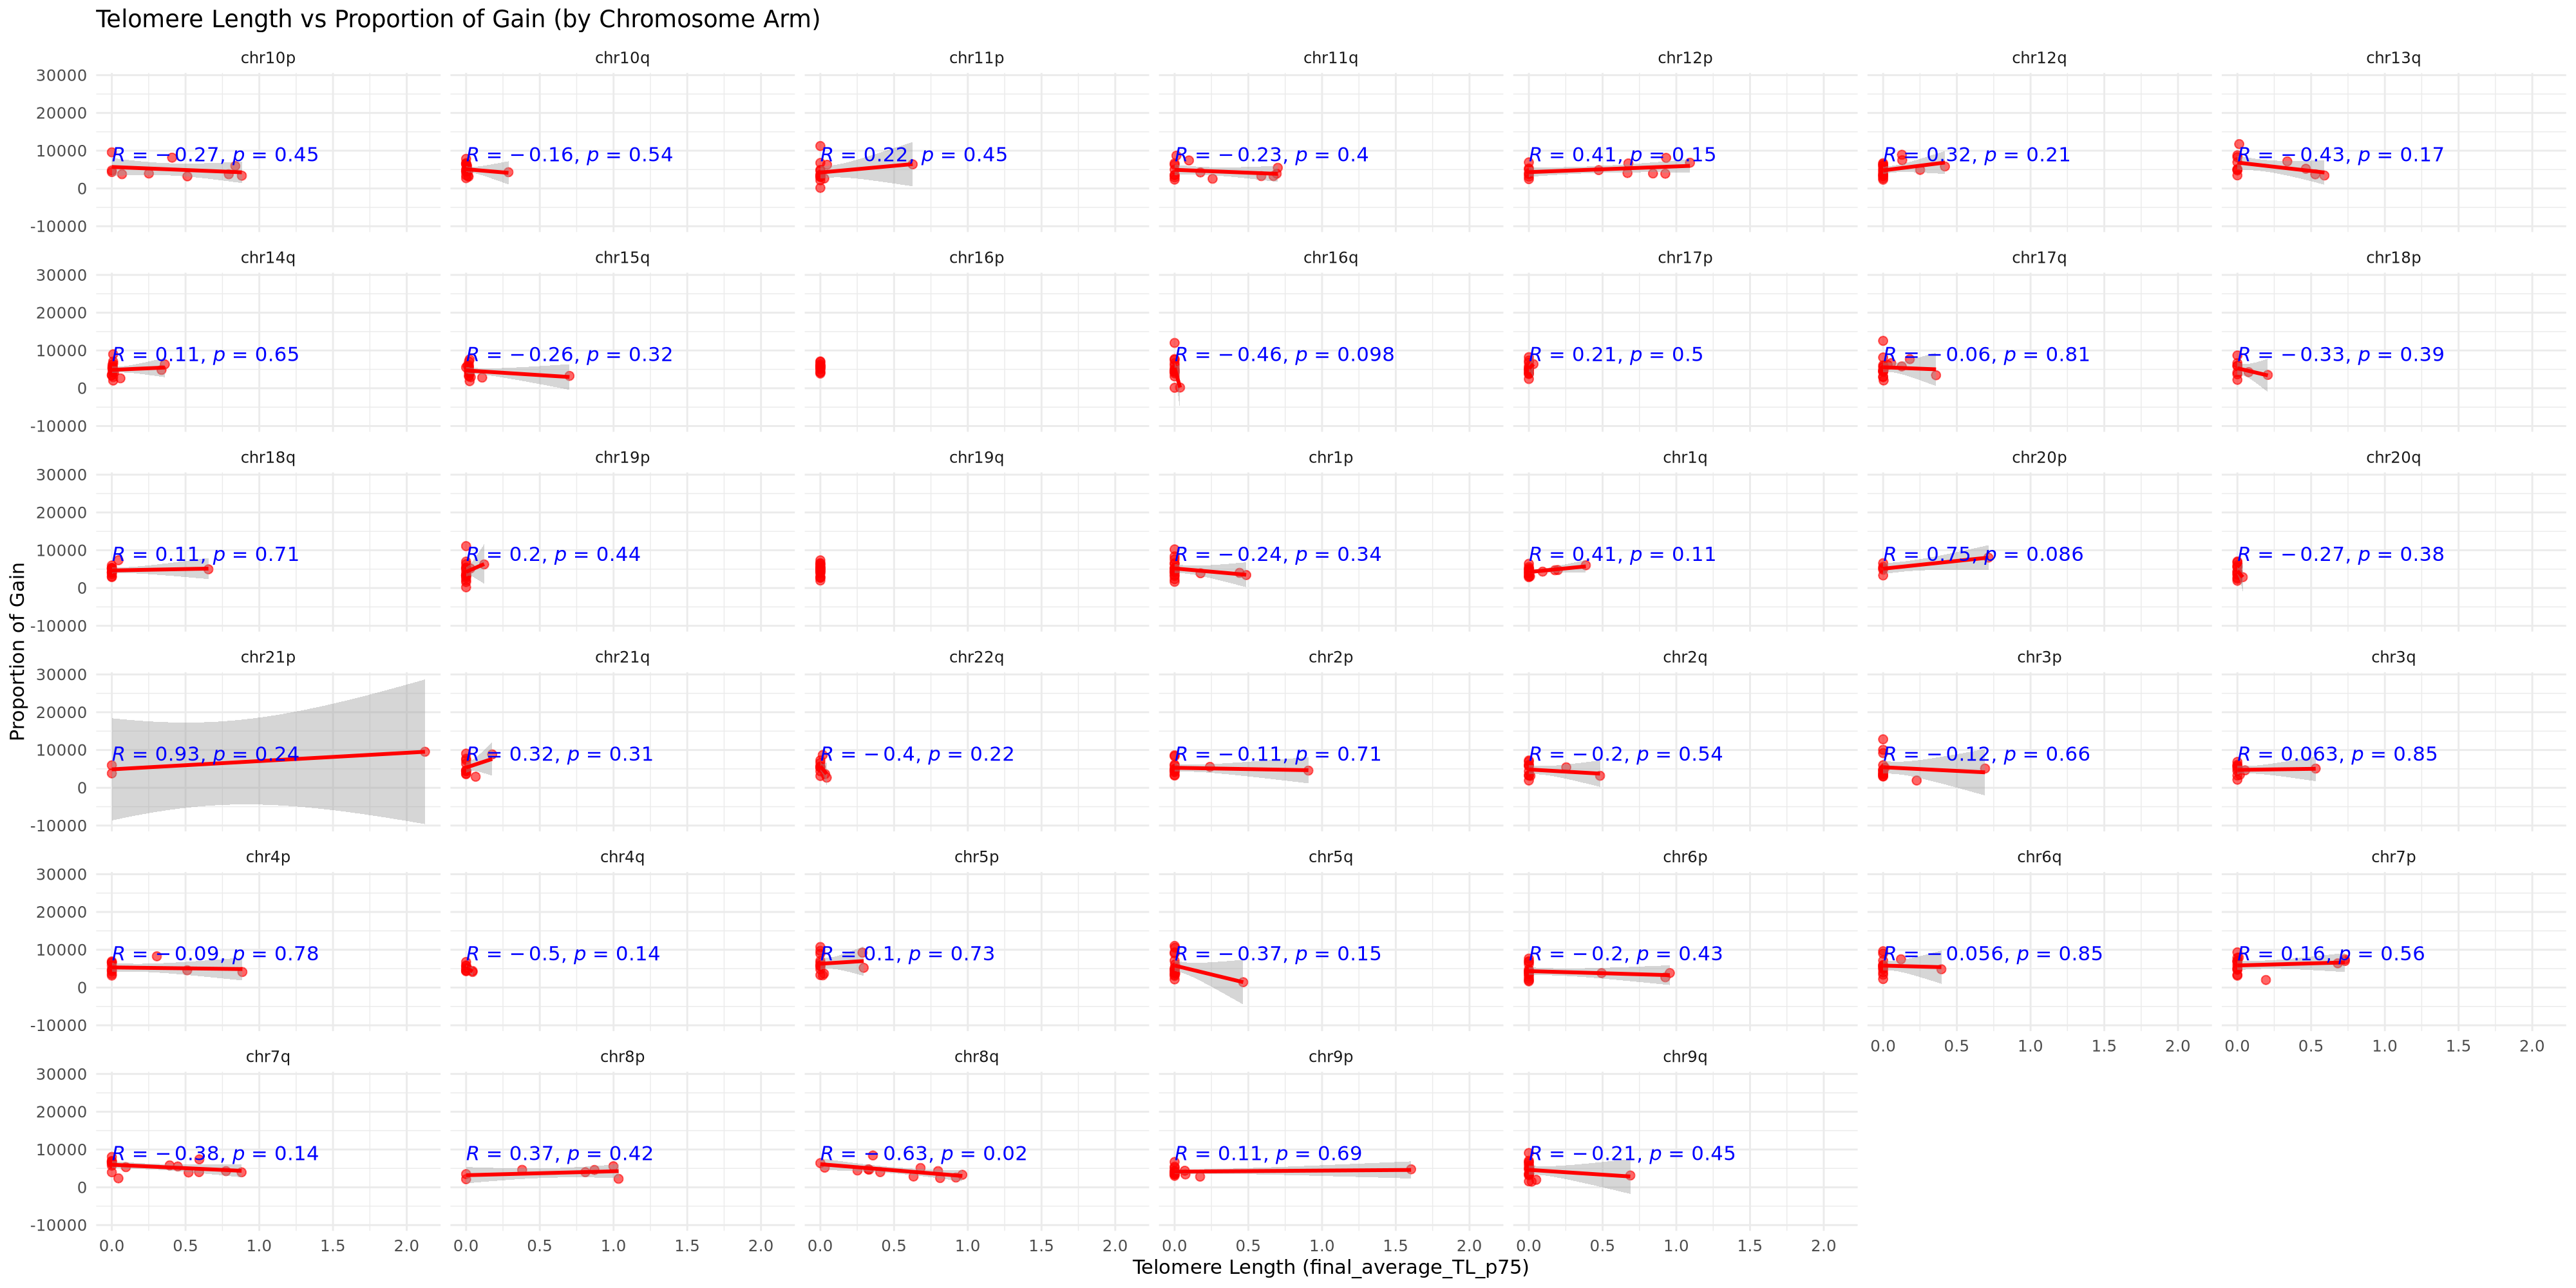

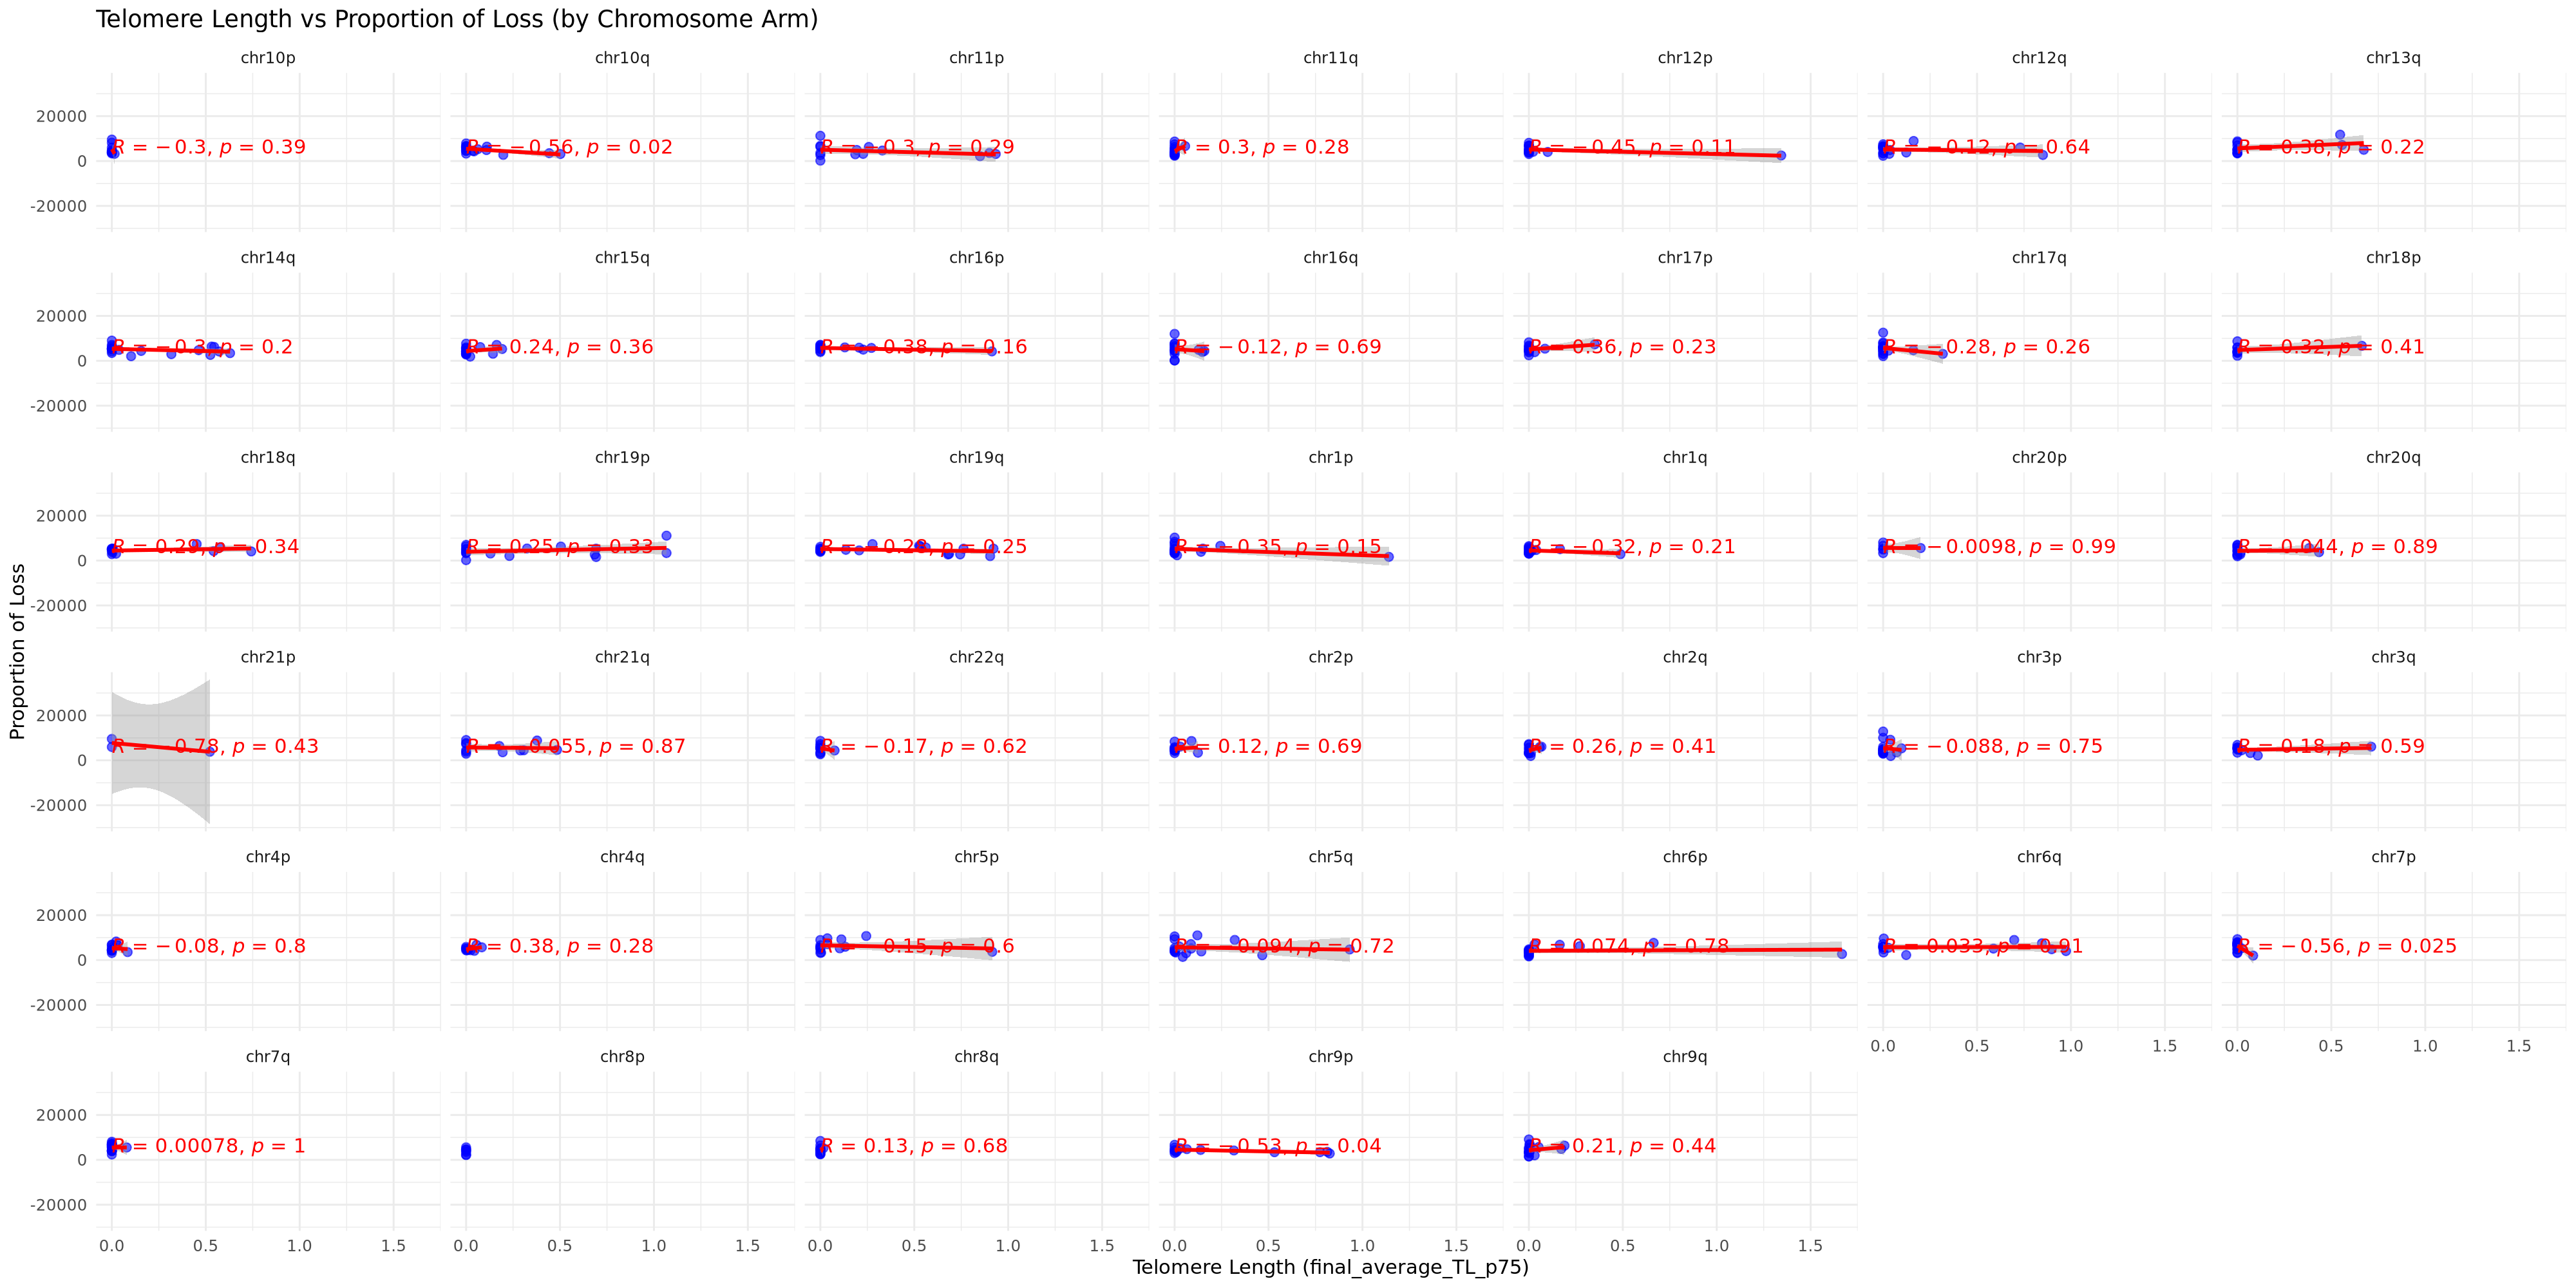

In [21]:
library(dplyr)
library(ggplot2)
library(ggpubr)

# Step 1: Merge telomere length data with proportions
merged_final_data <- proportion_summary %>%
  inner_join(
    telomeres,
    by = c("SampleID" = "Sample_prefix", "assigned_arm" = "chr")
  )

# Step 2: Perform correlation analysis for each chromosome arm, handling groups with insufficient data
facet_data <- merged_final_data %>%
  group_by(assigned_arm) %>%
  filter(n() >= 2) %>% # Only include groups with at least 2 observations
  summarize(
    pearson_corr_gain = cor(final_average_TL_p75, proportion_gain, use = "complete.obs"),
    p_value_gain = ifelse(n() >= 3, cor.test(final_average_TL_p75, proportion_gain)$p.value, NA),
    pearson_corr_loss = cor(final_average_TL_p75, proportion_loss, use = "complete.obs"),
    p_value_loss = ifelse(n() >= 3, cor.test(final_average_TL_p75, proportion_loss)$p.value, NA)
  )

print(facet_data)

# Step 3: Create combined plot with facets
# Gain plot
gain_plot <- ggplot(merged_final_data, aes(x = proportion_gain, y = final_average_TL_p75)) +
  geom_point(color = "red", size = 2, alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE, color = "red") +
  facet_wrap(~assigned_arm) +
  stat_cor(method = "pearson", label.x.npc = "left", label.y.npc = "top", color = "blue") +
  labs(
    x = "Telomere Length (final_average_TL_p75)",
    y = "Proportion of Gain",
    title = "Telomere Length vs Proportion of Gain (by Chromosome Arm)"
  ) +
  theme_minimal()

# Loss plot
loss_plot <- ggplot(merged_final_data, aes(x = proportion_loss, y = final_average_TL_p75)) +
  geom_point(color = "blue", size = 2, alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE, color = "red") +
  facet_wrap(~assigned_arm) +
  stat_cor(method = "pearson", label.x.npc = "left", label.y.npc = "top", color = "red") +
  labs(
    x = "Telomere Length (final_average_TL_p75)",
    y = "Proportion of Loss",
    title = "Telomere Length vs Proportion of Loss (by Chromosome Arm)"
  ) +
  theme_minimal()
options(repr.plot.width = 20, repr.plot.height = 10, repr.plot.res = 200)
# Step 4: Display the plots
print(gain_plot)
print(loss_plot)


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


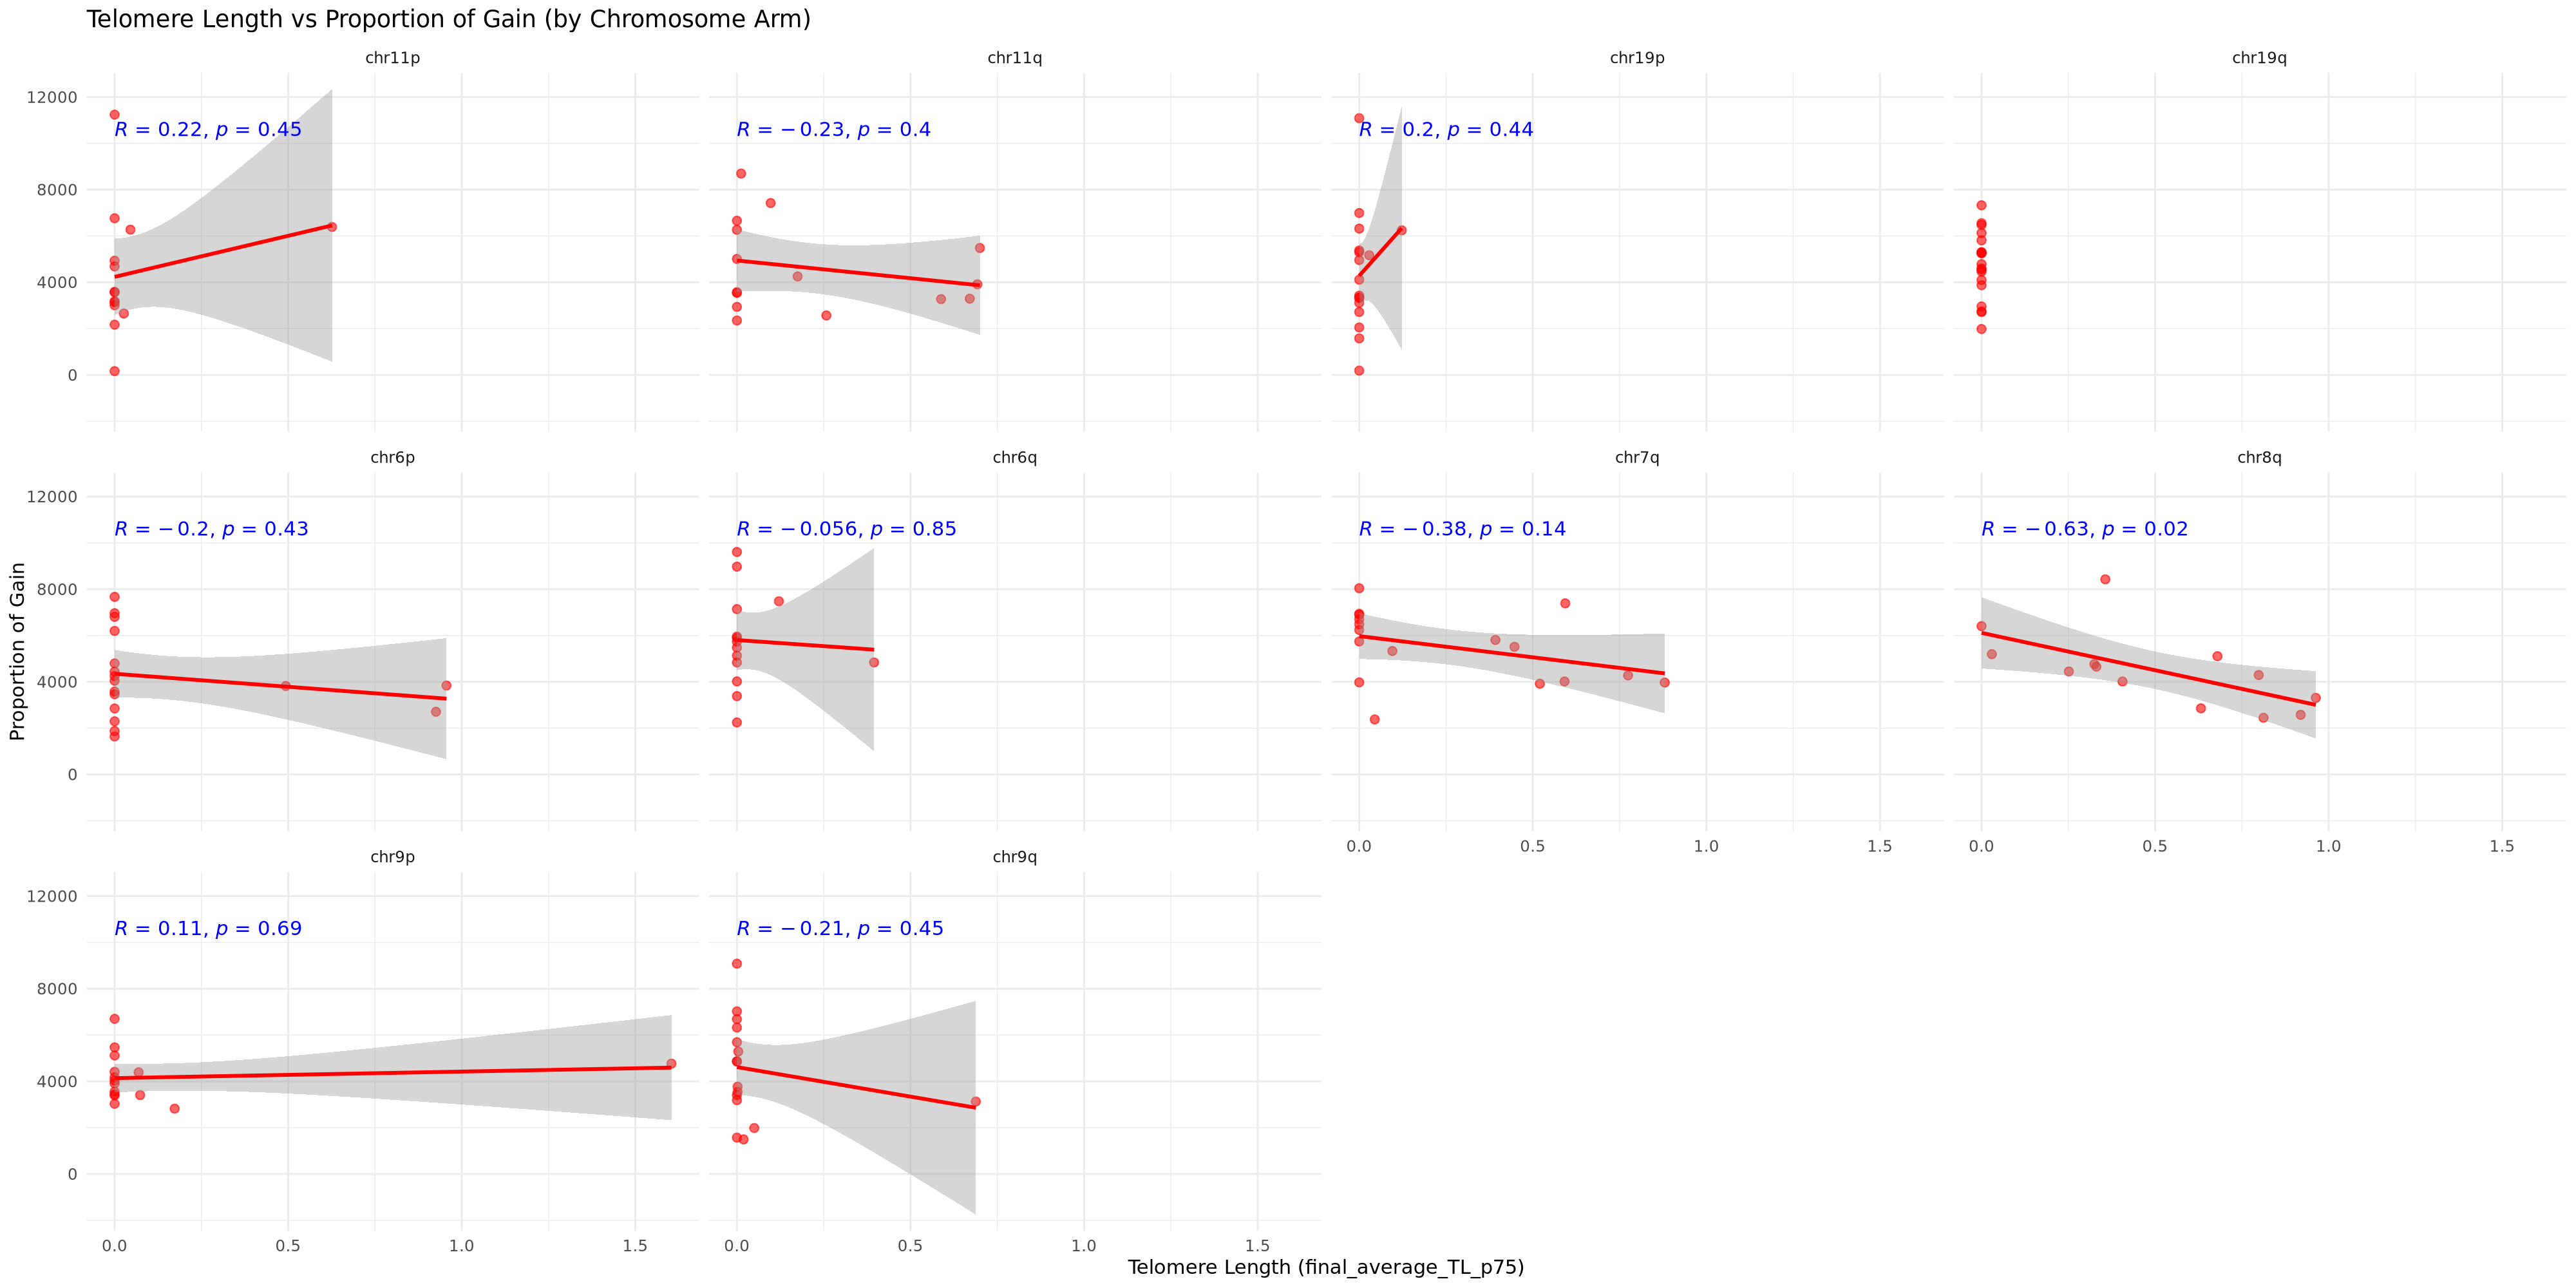

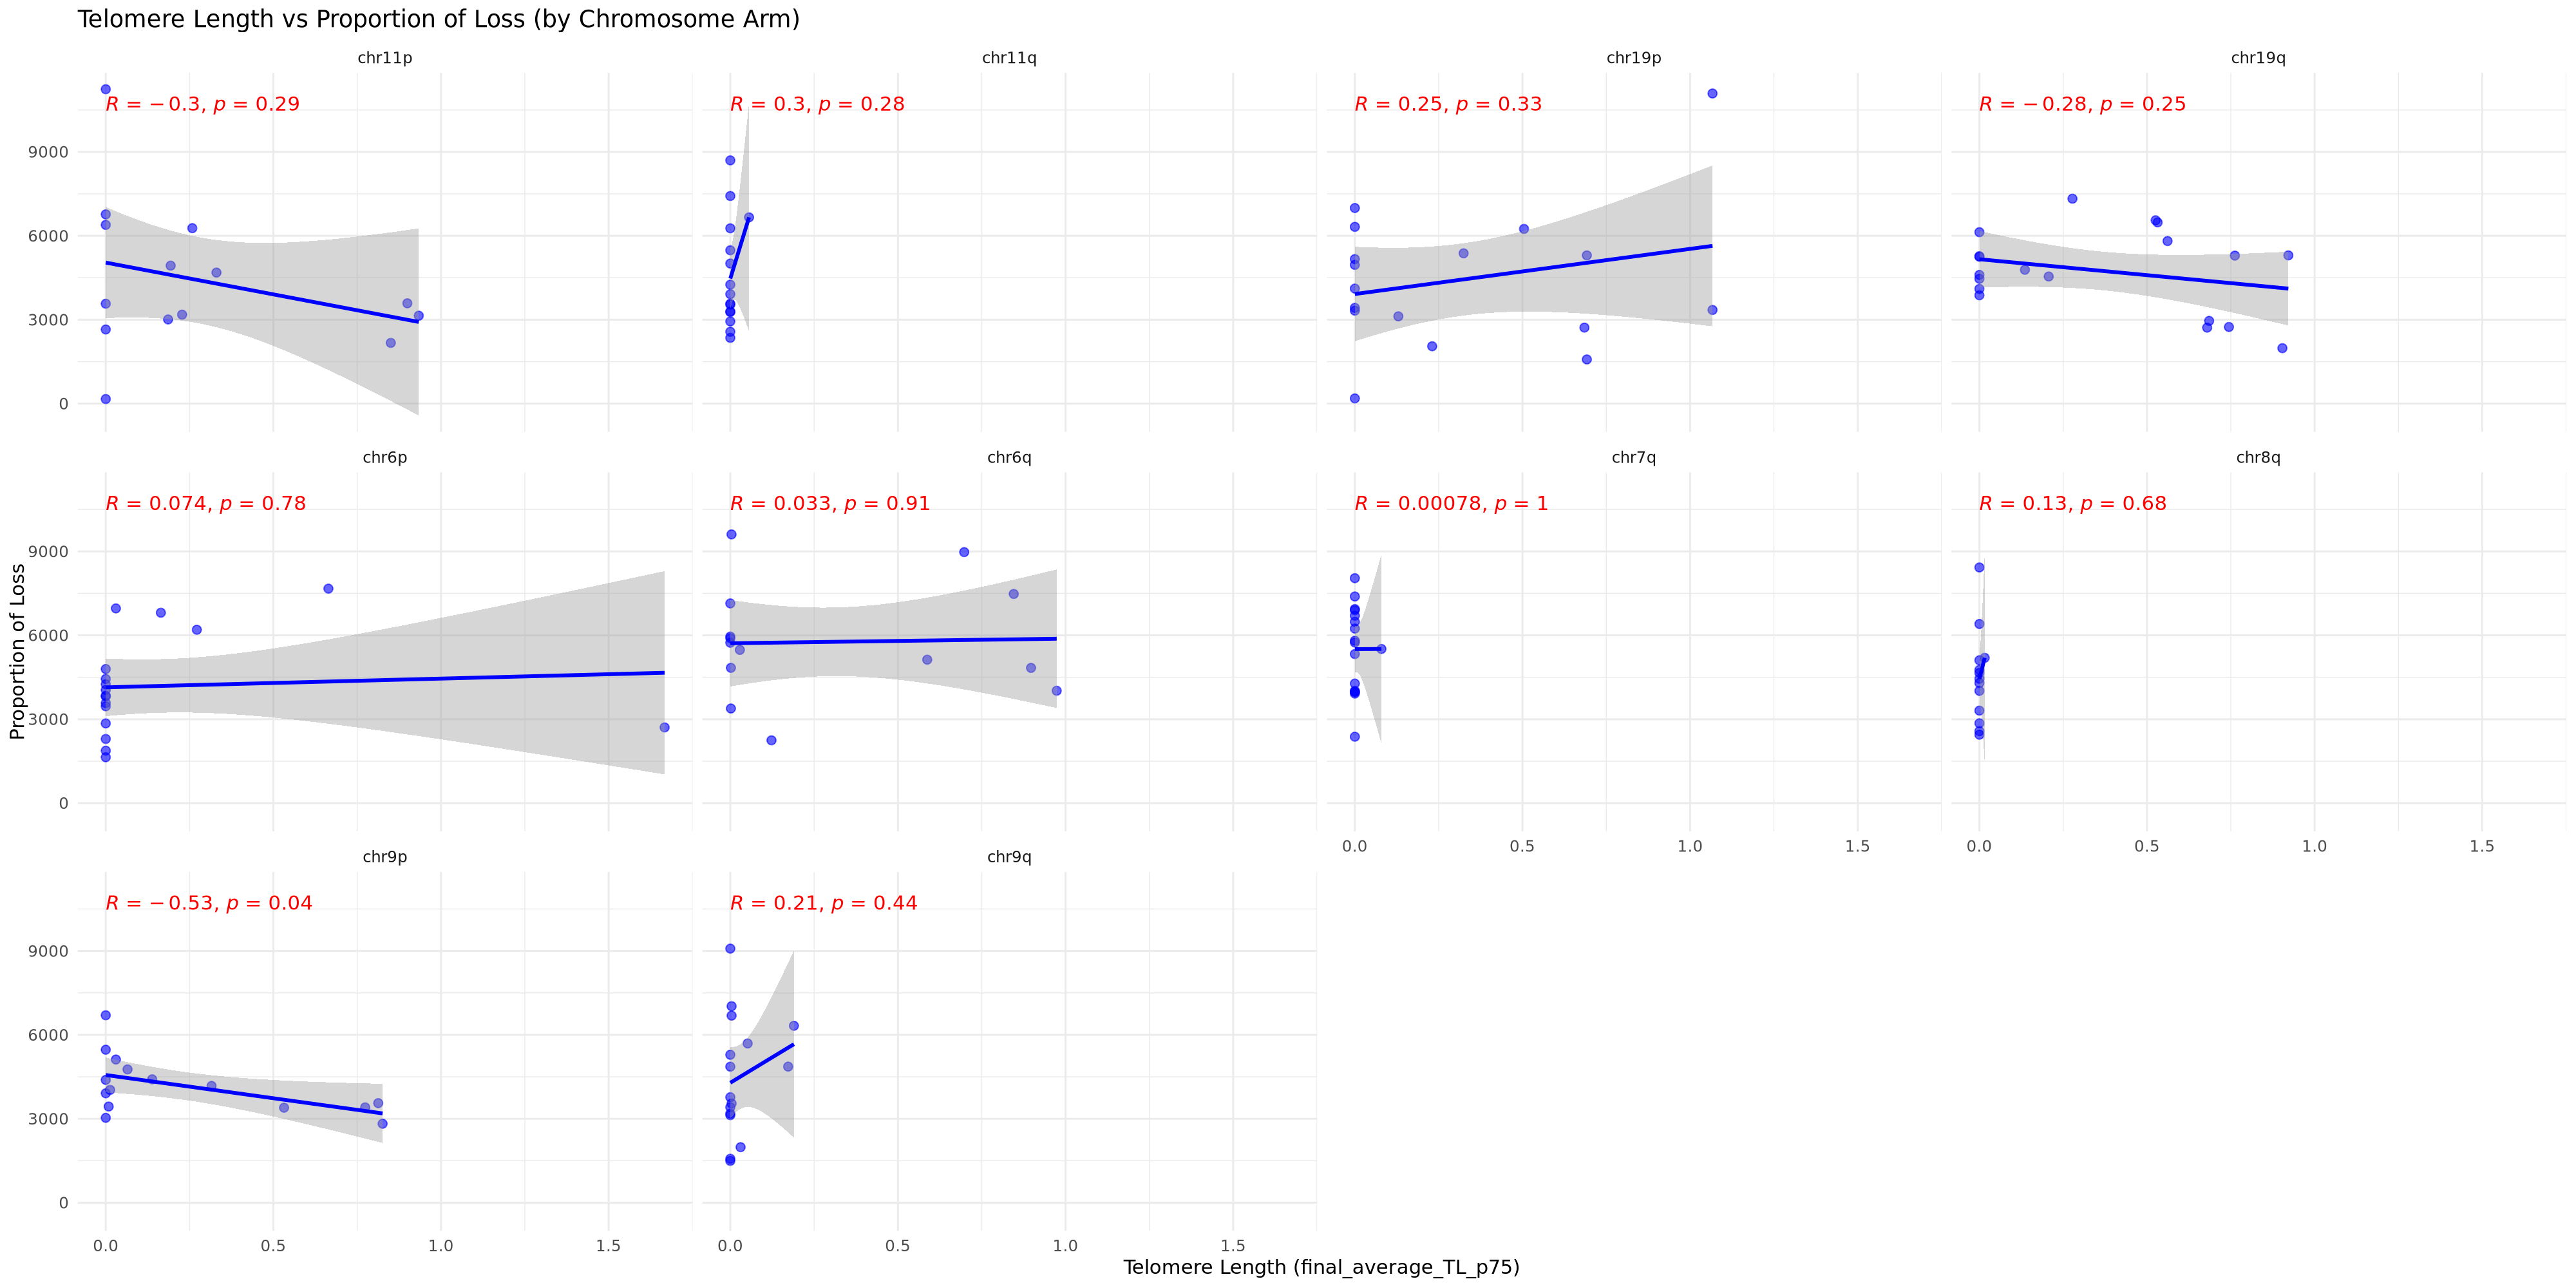

In [22]:
library(dplyr)
library(ggplot2)
library(ggpubr)

# Filter for specific chromosomes
filtered_chrs_data <- merged_final_data %>%
  filter(assigned_arm %in% c("chr6p", "chr6q", "chr9p", "chr9q", "chr11p", "chr11q", "chr19p", "chr19q", "chr7q", "chr8q"))

# Step 3: Create combined plot with facets
# Gain plot
gain_plot <- ggplot(filtered_chrs_data, aes(x = proportion_gain, y = final_average_TL_p75)) +
  geom_point(color = "red", size = 2, alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE, color = "red") +
  facet_wrap(~assigned_arm) +
  stat_cor(method = "pearson", label.x.npc = "left", label.y.npc = "top", color = "blue") +
  labs(
    x = "Telomere Length (final_average_TL_p75)",
    y = "Proportion of Gain",
    title = "Telomere Length vs Proportion of Gain (by Chromosome Arm)"
  ) +
  theme_minimal()

# Loss plot
loss_plot <- ggplot(filtered_chrs_data, aes(x = proportion_loss, y = final_average_TL_p75)) +
  geom_point(color = "blue", size = 2, alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE, color = "blue") +
  facet_wrap(~assigned_arm) +
  stat_cor(method = "pearson", label.x.npc = "left", label.y.npc = "top", color = "red") +
  labs(
    x = "Telomere Length (final_average_TL_p75)",
    y = "Proportion of Loss",
    title = "Telomere Length vs Proportion of Loss (by Chromosome Arm)"
  ) +
  theme_minimal()
options(repr.plot.width = 20, repr.plot.height = 10, repr.plot.res = 200)
# Step 4: Display the plots
print(gain_plot)
print(loss_plot)

In [23]:
telomeres2 <- telomeres %>%
  rename(assigned_arm = chr, SampleID =Sample_prefix)

In [24]:
head(telomeres2)

,SampleID,assigned_arm,final_average_TL_p75,chr_order,arm
,<chr>,<chr>,<dbl>,<int>,<chr>
1,2436A,chr1p,5221.000,1,p
2,2436A,chr1q,5051.167,1,q
3,3188,chr1p,1642.500,1,p
4,3188,chr1q,3086.500,1,q
5,3988,chr1p,2347.500,1,p
6,3988,chr1q,5083.000,1,q


In [25]:
head(merged_data)

,SampleID,chr,START,END,num.mark,MEAN_LOG2_COPY_RATIO,assigned_arm,Start,End,Length,classification
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,2436A,chr1,200151,28021140,130,0.8417,chr1p,0,124048267,124048267,neutral
2,2436A,chr1,142707663,142907814,2,2.1416,chr1q,124048267,248387328,124339061,gain
3,2436A,chr10,88303635,101719380,68,0.7949,chr10q,40649191,134758134,94108943,neutral
4,2436A,chr10,101919615,104722905,15,0.6843,chr10q,40649191,134758134,94108943,neutral
5,2436A,chr10,104923140,112932540,41,0.7685,chr10q,40649191,134758134,94108943,neutral
6,2436A,chr10,113132775,120741705,39,0.3861,chr10q,40649191,134758134,94108943,loss


In [26]:


# Step 2: Count gains, losses, and neutrals for each arm in each sample
arm_counts <- merged_data %>%
  group_by(SampleID, assigned_arm, classification) %>%
  summarize(
    count = n(),  # Count the number of segments
    .groups = "drop"
  ) %>%
  pivot_wider(
    names_from = classification,
    values_from = count,
    values_fill = 0  # Fill missing values with 0
  )

# Step 3: Merge with telomere length data
# Replace 'telomeres2' with your actual dataset
count_data <- arm_counts %>%
  left_join(
    telomeres2,
    by = c("SampleID", "assigned_arm")
  )

# Step 4: Calculate correlations
# Correlation for gains
cor_gain <- cor.test(count_data$gain, count_data$final_average_TL_p75, method = "spearman")

# Correlation for losses
cor_loss <- cor.test(count_data$loss, count_data$final_average_TL_p75, method = "spearman")

# Print correlation results
cat("Correlation for Gains:\n")
print(cor_gain)

cat("\nCorrelation for Losses:\n")
print(cor_loss)



Warning message in cor.test.default(count_data$gain, count_data$final_average_TL_p75, :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(count_data$loss, count_data$final_average_TL_p75, :
“Cannot compute exact p-value with ties”


Correlation for Gains:

	Spearman's rank correlation rho

data:  count_data$gain and count_data$final_average_TL_p75
S = 30494672, p-value = 0.09812
alternative hypothesis: true rho is not equal to 0
sample estimates:
        rho 
-0.07028065 


Correlation for Losses:

	Spearman's rank correlation rho

data:  count_data$loss and count_data$final_average_TL_p75
S = 30812435, p-value = 0.0552
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
-0.0814333 



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 31 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 31 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 31 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 31 rows containing missing values or values outside the scale range
(`geom_point()`).”


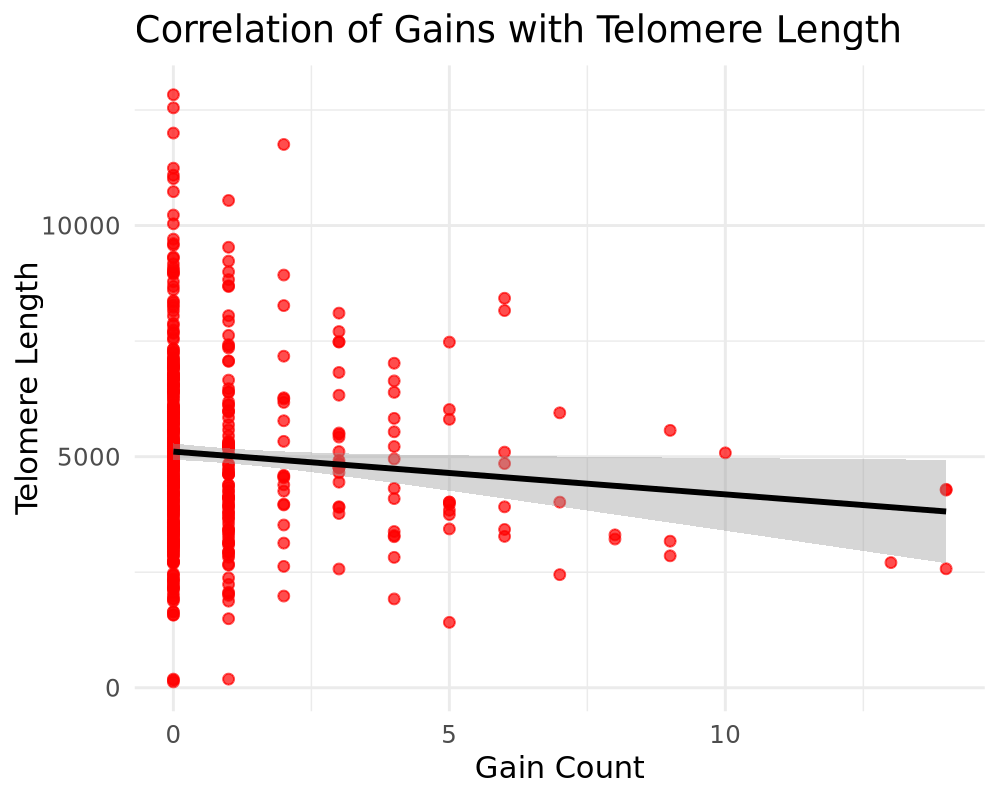

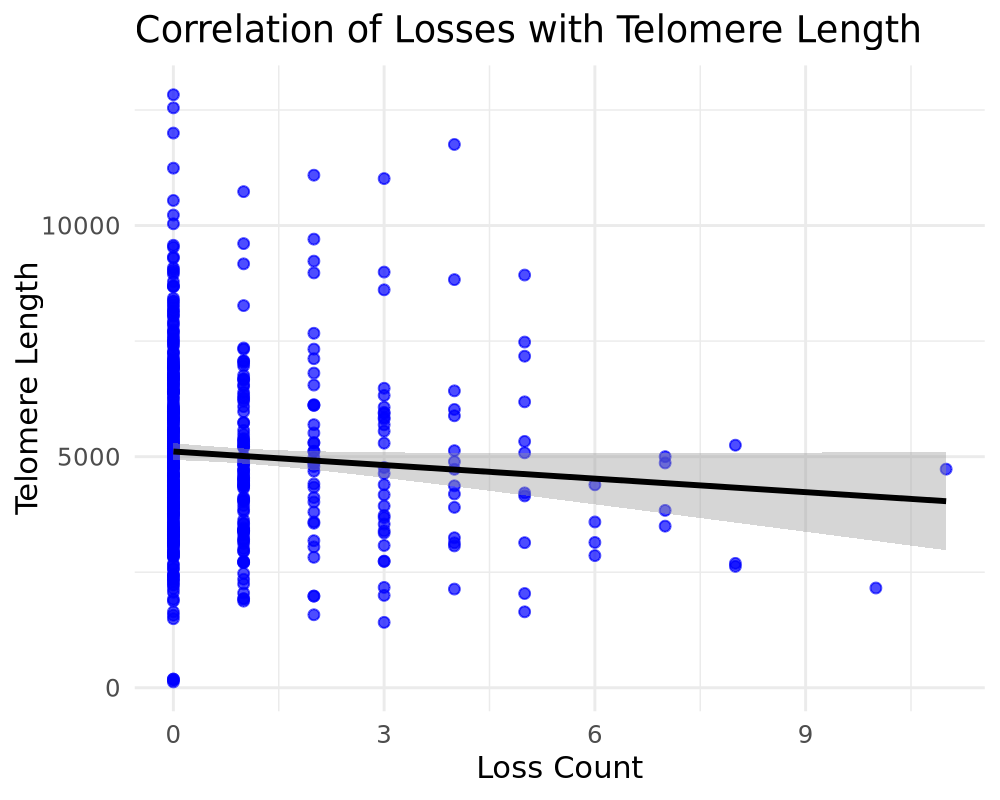

In [27]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)

# Scatterplot for gains
ggplot(count_data, aes(x = gain, y = final_average_TL_p75)) +
  geom_point(alpha = 0.7, color = "red") +
  geom_smooth(method = "lm", se = TRUE, color = "black") +
  labs(
    title = "Correlation of Gains with Telomere Length",
    x = "Gain Count",
    y = "Telomere Length"
  ) +
  theme_minimal()

# Scatterplot for losses
ggplot(count_data, aes(x = loss, y = final_average_TL_p75)) +
  geom_point(alpha = 0.7, color = "blue") +
  geom_smooth(method = "lm", se = TRUE, color = "black") +
  labs(
    title = "Correlation of Losses with Telomere Length",
    x = "Loss Count",
    y = "Telomere Length"
  ) +
  theme_minimal()


In [28]:
head(count_data)  

SampleID,assigned_arm,loss,neutral,gain,final_average_TL_p75,chr_order,arm
<chr>,<chr>,<int>,<int>,<int>,<dbl>,<int>,<chr>
2436A,chr10q,3,4,0,2732.75,10,q
2436A,chr11p,0,1,0,6766.00,11,p
2436A,chr12p,0,1,0,5319.40,12,p
2436A,chr12q,0,3,0,6085.00,12,q
2436A,chr14q,0,1,0,3490.60,14,q
2436A,chr15q,0,0,1,4111.50,15,q


In [29]:
summary(merged_data$Length)


     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
 11134529  52743313  89761231  83037276 100988875 149193469 

In [31]:
library(scales)
library(ggplot2)

# Calculate the length for each segment
length_data <- segmentation %>%
  mutate(Length = loc.end - loc.start)

# Convert Length to kilobases (kb)
length_data <- length_data %>%
  mutate(Length_kb = Length / 1000)

# Categorize the data based on MEAN_LOG2_COPY_RATIO
length_data <- length_data %>%
  mutate(Category = case_when(
    seg.mean < 0.66 ~ "Loss",  # Loss category for MEAN_LOG2_COPY_RATIO < 1.3
    seg.mean > 1.15 ~ "Gain",    # Gain category for MEAN_LOG2_COPY_RATIO > 1
    TRUE ~ NA_character_
  )) %>%
  filter(!is.na(Category))  # Keep only Loss and Gain

# Custom function to format y-axis labels as either kb or Mb
format_labels <- function(x) {
  ifelse(x < 1000, 
         paste0(round(x, 1), " kb"), 
         paste0(round(x / 1000, 1), " Mb"))
}

# Create violin plot based on length and category
ggplot(length_data, aes(x = Category, y = Length_kb, fill = Category)) +
  geom_violin(trim = FALSE, alpha = 0.7) +
  labs(
    title = "Distribution of Lengths by Category",
    x = "Category",
    y = "Length"
  ) +
  scale_y_continuous(labels = format_labels) +  # Apply custom label formatting
  theme_minimal() +
  scale_fill_manual(values = c("Loss" = "blue", "Gain" = "red"))
options(repr.plot.width = 5, repr.plot.height = 3.5, repr.plot.res = 200)

ERROR: [1m[33mError[39m in `mutate()`:[22m
[1m[22m[36mℹ[39m In argument: `Length = loc.end - loc.start`.
[1mCaused by error:[22m
[33m![39m object 'loc.end' not found


In [32]:
head(length_data)

ERROR: Error: object 'length_data' not found


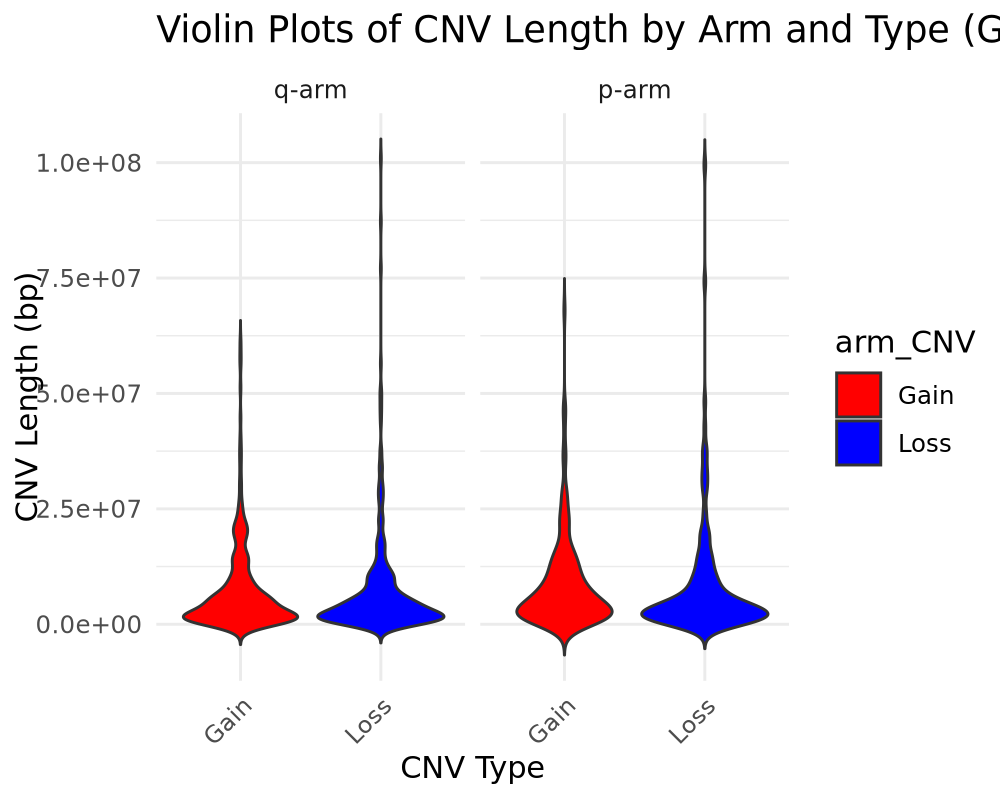

In [33]:
merged_data <- merged_data %>%
  mutate(CNV_Length = END - START)

# Step 2: Classify CNV Type based on MEAN_LOG2_COPY_RATIO
merged_data <- merged_data %>%
  mutate(CNV_Type = case_when(
    MEAN_LOG2_COPY_RATIO > 1.15 ~ "Gain",
    MEAN_LOG2_COPY_RATIO < 0.66 ~ "Loss",
    TRUE ~ "Neutral"
  ))

# Step 3: Filter for Gain and Loss CNV types only
merged_data_filtered <- merged_data %>%
  filter(CNV_Type %in% c("Gain", "Loss"))

# Step 4: Filter to include both p and q arms across all chromosomes
merged_data_filtered <- merged_data_filtered %>%
  filter(grepl("p$", assigned_arm) | grepl("q$", assigned_arm))

# Step 5: Create a new column combining arm and CNV type for easy plotting
merged_data_filtered <- merged_data_filtered %>%
  mutate(arm_CNV = case_when(
    grepl("p$", assigned_arm) & CNV_Type == "Gain" ~ "Gain",
    grepl("p$", assigned_arm) & CNV_Type == "Loss" ~ "Loss",
    grepl("q$", assigned_arm) & CNV_Type == "Gain" ~ "Gain",
    grepl("q$", assigned_arm) & CNV_Type == "Loss" ~ "Loss"
  ))

# Step 6: Create the violin plots
ggplot(merged_data_filtered, aes(x = arm_CNV, y = CNV_Length, fill = arm_CNV)) +
  geom_violin(trim = FALSE) +
  labs(title = "Violin Plots of CNV Length by Arm and Type (Gain/Loss)", 
       x = "CNV Type", 
       y = "CNV Length (bp)") +
  theme_minimal() +
  scale_fill_manual(values = c("Gain" = "red", "Loss" = "blue")) +
  facet_wrap(~ grepl("p$", assigned_arm), labeller = as_labeller(c(`TRUE` = "p-arm", `FALSE` = "q-arm"))) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))  # Rotate x labels for readability
options(repr.plot.width = 6, repr.plot.height = 3.5, repr.plot.res = 200)

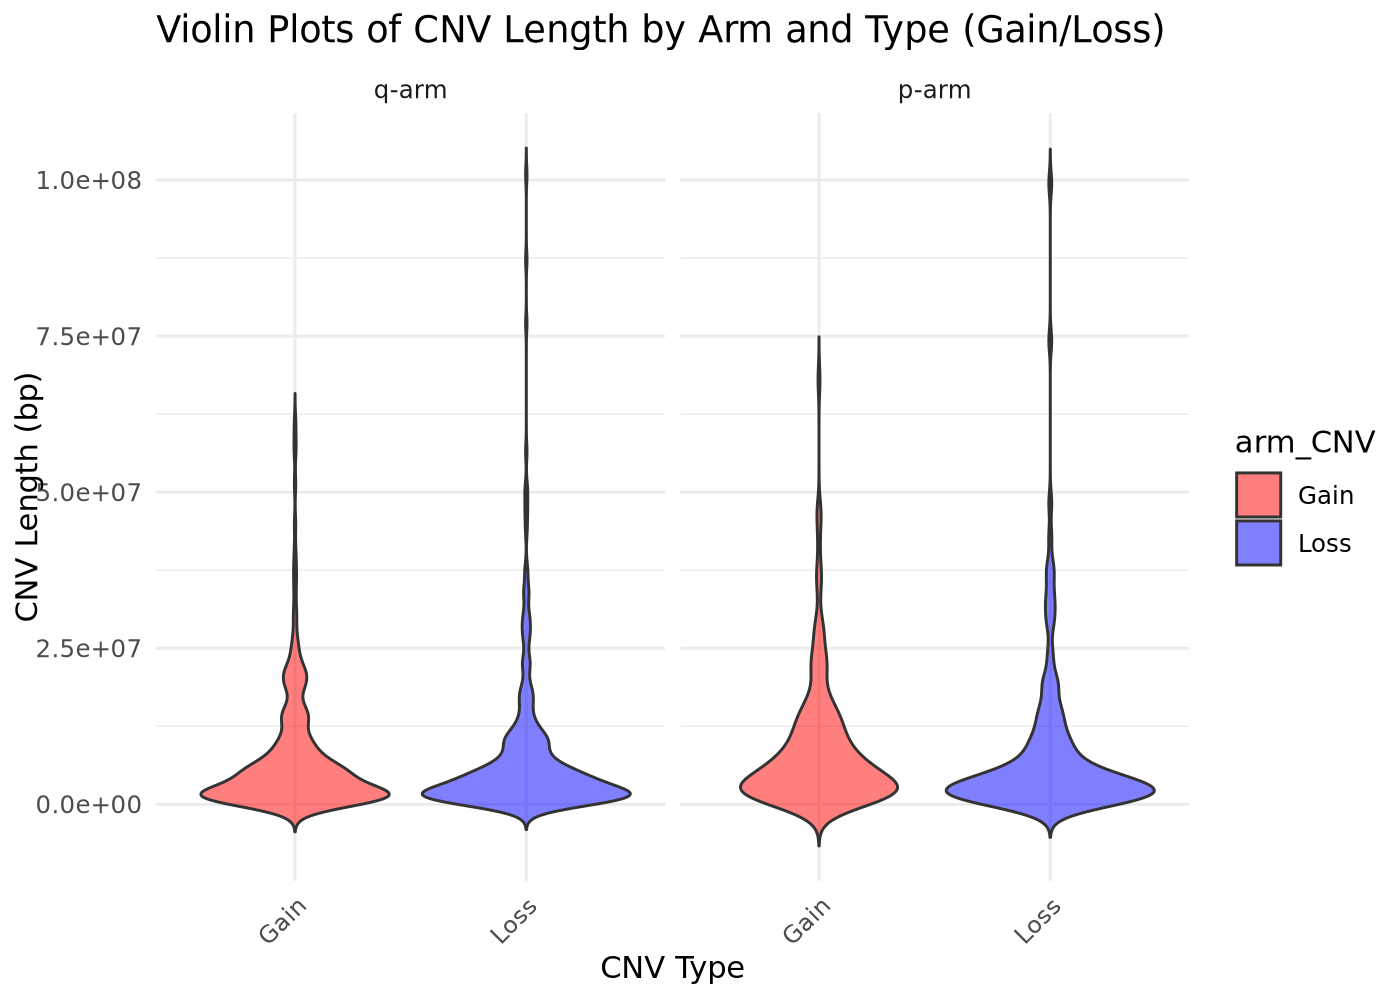

In [34]:
options(repr.plot.width = 7, repr.plot.height = 5, repr.plot.res = 200)
# Step 6: Create the violin plots
ggplot(merged_data_filtered, aes(x = arm_CNV, y = CNV_Length, fill = arm_CNV)) +
  geom_violin(trim = FALSE, alpha = 0.5) +
  labs(title = "Violin Plots of CNV Length by Arm and Type (Gain/Loss)", 
       x = "CNV Type", 
       y = "CNV Length (bp)") +
  theme_minimal() +
  scale_fill_manual(values = c("Gain" = "red", "Loss" = "blue")) +
  facet_wrap(~ grepl("p$", assigned_arm), labeller = as_labeller(c(`TRUE` = "p-arm", `FALSE` = "q-arm"))) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))  # Rotate x labels for readability


In [35]:
head(merged_final_data)

SampleID,chr,assigned_arm,Length,total_length_neutral,total_length_gain,total_length_loss,proportion_neutral,proportion_gain,proportion_loss,final_average_TL_p75,chr_order,arm
<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
2436A,chr1,chr1p,124048267,27820989,0,0,0.22427552,0.000000000,0.0000000,5221.000,1,p
2436A,chr1,chr1q,124339061,0,200151,0,0.00000000,0.001609719,0.0000000,5051.167,1,q
2436A,chr10,chr10q,94108943,26230785,0,18621836,0.27872787,0.000000000,0.1978753,2732.750,10,q
2436A,chr11,chr11p,52743313,3002850,0,0,0.05693328,0.000000000,0.0000000,6766.000,11,p
2436A,chr12,chr12p,35911664,4003740,0,0,0.11148857,0.000000000,0.0000000,5319.400,12,p
2436A,chr12,chr12q,97412884,9809163,0,0,0.10069677,0.000000000,0.0000000,6085.000,12,q


In [ ]:
# Save the data as a TSV file
write.table(merged_final_data, file = "CNVs_TEL_merged_final_data.tsv", sep = "\t", row.names = FALSE, quote = FALSE)


In [ ]:
getwd()